In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [3]:
!pip install ipython-autotime
%load_ext autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.2 MB/s eta 0:00:00
time: 204 µs (started: 2025-12-16 08:45:59 +00:00)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import os
import csv
from keras.models import load_model

time: 1.36 s (started: 2025-12-16 08:46:01 +00:00)


Mounting Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
time: 20 s (started: 2025-12-16 08:46:05 +00:00)


## Customizable Variables

Dataset

In [6]:
dataset_path = '/content/drive/MyDrive/CSE425 Project/Preprocessed/Negative Image'
number_of_classes = 2
img_height = 224
img_width = 224
batch_size = 16

time: 566 µs (started: 2025-12-16 08:46:26 +00:00)


Pre-trained Model

In [7]:
ResNet101 = tf.keras.applications.ResNet101(include_top=False, weights="imagenet", input_shape=(224,224,3))   #change here

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
time: 5.22 s (started: 2025-12-16 08:46:29 +00:00)


Save File Paths

In [8]:
training_model_save_path = '/content/drive/MyDrive/CSE425 Project/Preprocessing Result/Negative Image Result/ResNet101/training_model.keras'
training_history_save_path = '/content/drive/MyDrive/CSE425 Project/Preprocessing Result/Negative Image Result/ResNet101/training_history.csv'
training_history_plot_save_path = '/content/drive/MyDrive/CSE425 Project/Preprocessing Result/Negative Image Result/ResNet101/training_history.png'
training_confusion_matrix_save_path = '/content/drive/MyDrive/CSE425 Project/Preprocessing Result/Negative Image Result/ResNet101/training_confusion_matrix.png'
training_roc_curve_save_path = '/content/drive/MyDrive/CSE425 Project/Preprocessing Result/Negative Image Result/ResNet101/training_roc_curve.png'

accuracy_loss_csv_path = '/content/drive/MyDrive/CSE425 Project/Preprocessing Result/Negative Image Result/ResNet101/AccuracyLossCurves.csv' # Combined history of training and fine tuning stage
roc_auroc_csv_path = '/content/drive/MyDrive/CSE425 Project/Preprocessing Result/Negative Image Result/ResNet101/ROCandAUROC.csv' # Combined roc data of training and fine tuning
confusion_matrix_csv_path = '/content/drive/MyDrive/CSE425 Project/Preprocessing Result/Negative Image Result/ResNet101/ConfusionMat.csv' # Combined confusion matrix data of training and fine tuning

time: 1.09 ms (started: 2025-12-16 08:46:35 +00:00)


Hyper Parameters (Initial Training)

**Note:** `tf.keras.losses.BinaryCrossentropy` is recommended for Binary Classification

In [ ]:
training_epochs = 30
training_learning_rate = 0.0001
training_loss = tf.keras.losses.BinaryCrossentropy(from_logits=False)  # Binary classification
training_optimizer = tf.keras.optimizers.Adam(learning_rate=training_learning_rate)
training_metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]  # Added AUC for binary
training_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(training_model_save_path, save_weights_only=False, save_best_only=True, mode='min'),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(),
]


time: 12.9 ms (started: 2025-12-09 23:29:45 +00:00)


## Load and Preprocess Data

In [9]:
def generate_dataset(dataset_path, batch_size, img_height, img_width):
  """
    Generates TensorFlow datasets for training, validation and testing from a directory.

    Args:
    - dataset_path (str): Path to the directory containing the dataset.
    - batch_size (int): Batch size for the datasets.
    - img_height (int): Height of the images in the datasets.
    - img_width (int): Width of the images in the datasets.

    Returns:
    - train_dataset (tf.data.Dataset): TensorFlow dataset for training.
    - validation_dataset (tf.data.Dataset): TensorFlow dataset for validation.
    - test_dataset (tf.data.Dataset): TensorFlow dataset for testing.

    This function creates TensorFlow datasets for training validation and testing from a directory containing image data.
  """

  # Create train dataset
  train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
      directory='/content/drive/MyDrive/CSE425 Project/Preprocessed/Negative Image/Negative Dataset/Train',
      image_size=(img_height, img_width),
      batch_size=batch_size,
  )

  # Create validation dataset
  validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
      directory='/content/drive/MyDrive/CSE425 Project/Preprocessed/Negative Image/Negative Dataset/Validation',
      image_size=(img_height, img_width),
      batch_size=batch_size,
  )

  # Create test dataset
  test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
      directory='/content/drive/MyDrive/CSE425 Project/Preprocessed/Negative Image/Negative Dataset/Test',
      image_size=(img_height, img_width),
      batch_size=batch_size,
  )

  return train_dataset, validation_dataset, test_dataset

time: 1.07 ms (started: 2025-12-16 08:46:40 +00:00)


In [10]:
train_ds, validation_ds, test_ds = generate_dataset(dataset_path, batch_size, img_height, img_width)

Found 860 files belonging to 2 classes.
Found 288 files belonging to 2 classes.
Found 286 files belonging to 2 classes.
time: 6.71 s (started: 2025-12-16 08:46:43 +00:00)


## Model Architecture

Get all the class names

In [11]:
class_names = test_ds.class_names
print(class_names)

['Fractured', 'Non Fractured']
time: 479 µs (started: 2025-12-16 08:46:51 +00:00)


In [ ]:
def generate_model(pretrained_model, number_of_classes):
  """
  Generates a binary classification model on top of a pre-trained base.
  Output: single sigmoid neuron for binary classification.
  """

  for layer in pretrained_model.layers:
      layer.trainable = False

  x = pretrained_model.output
  x = tf.keras.layers.GlobalAveragePooling2D()(x)  # Replaces Flatten after conv output
  x = tf.keras.layers.Dense(512, activation='relu')(x)
  x = tf.keras.layers.Dropout(0.5)(x)
  x = tf.keras.layers.Dense(256, activation='relu')(x)
  x = tf.keras.layers.Dropout(0.3)(x)
  # Single sigmoid output for binary classification
  prediction = tf.keras.layers.Dense(1, activation='sigmoid')(x)

  model = tf.keras.models.Model(inputs=pretrained_model.input, outputs=prediction)
  return model



time: 3.76 ms (started: 2025-12-09 23:29:46 +00:00)


In [ ]:
model = generate_model(ResNet101, number_of_classes)   #change here

time: 78.6 ms (started: 2025-12-09 23:29:46 +00:00)


## Initial Training

In [ ]:
def train(model, epochs, learning_rate, loss, optimizer, metrics, callbacks, train_ds, validation_ds, model_save_path, history_save_path):
    """
    Trains a TensorFlow or Keras model on training and validation datasets.

    Args:
    - model (tf.keras.Model): TensorFlow or Keras model to train.
    - epochs (int): Number of epochs for training.
    - learning_rate (float): Learning rate for the optimizer.
    - loss (tf.keras.losses.Loss): Loss function to optimize.
    - optimizer (tf.keras.optimizers.Optimizer): Optimizer to use during training.
    - metrics (list): List of metrics to evaluate during training.
    - callbacks (list): List of callbacks to apply during training.
    - train_ds (tf.data.Dataset): TensorFlow dataset for training.
    - validation_ds (tf.data.Dataset): TensorFlow dataset for validation.
    - model_save_path (str): File path to save the trained model weights.
    - history_save_path (str): File path to save the training history as a CSV file.

    Returns:
    - history (tf.keras.callbacks.History): Training history containing loss and metrics.

    This function compiles and trains a TensorFlow or Keras model on the specified training and validation datasets.
    It compiles the model with the specified optimizer, loss function, and metrics, then trains the model for the
    specified number of epochs. Training progress is monitored using the provided callbacks. After training, the
    training history is saved as a CSV file and the trained model weights are loaded from the specified file path.
    The training history is returned for further analysis or visualization.
    """
    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=metrics
    )

    # Train the model
    history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=epochs,
        callbacks=callbacks
    )

    # Save training history to CSV file
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(history_save_path, index=False)

    # Load best model weights
    model = load_model(model_save_path)

    return history

time: 2.79 ms (started: 2025-12-09 23:29:46 +00:00)


In [ ]:
tf.config.run_functions_eagerly(True)
training_optimizer = tf.keras.optimizers.Adam(learning_rate = training_learning_rate)

training_history = train(model,
                training_epochs,
                training_learning_rate,
                training_loss,
                training_optimizer,
                training_metrics,
                training_callbacks,
                train_ds,
                validation_ds,
                training_model_save_path,
                training_history_save_path)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.5122 - loss: 1.4491 - val_accuracy: 0.7118 - val_loss: 0.5961 - learning_rate: 1.0000e-04
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7466 - loss: 0.6407 - val_accuracy: 0.7118 - val_loss: 0.5460 - learning_rate: 1.0000e-04
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.7903 - loss: 0.5039 - val_accuracy: 0.7153 - val_loss: 0.5326 - learning_rate: 1.0000e-04
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8568 - loss: 0.3391 - val_accuracy: 0.7292 - val_loss: 0.5313 - learning_rate: 1.0000e-04
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8788 - loss: 0.2690 - val_accuracy: 0.7431 - val_loss: 0.5562 - learning_rate: 1.0000e-04
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9224 - loss: 0.2137 - val_accuracy: 0.7188 - val_loss: 0.5983 - learning_rate: 1.0000e-04
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9045 - loss:

Evaluate the model on test dataset

In [ ]:
model.evaluate(test_ds, return_dict=True)

18/18 ━━━━━━━━━━━━━━━━━━━━ 100s 5s/step - accuracy: 0.7998 - loss: 0.4827


{'accuracy': 0.7587412595748901, 'loss': 0.546241283416748}

time: 1min 40s (started: 2025-12-09 23:40:03 +00:00)


## Evaluation Metrics

Write functions to plot different diagrams and charts to evaluate and understand the model's performance.

Plots the Model's training history to see how the model evolved throughout the epochs

In [12]:
def plot_history(history, save_path):
    """
    Plots the training history of a TensorFlow or Keras model.

    Args:
    - history (tf.keras.callbacks.History): Training history containing loss and metrics.
    - save_path (str): File path to save the plot as an image.

    This function takes the training history of a TensorFlow or Keras model and plots the training and validation
    loss as well as the training and validation accuracy over epochs. The resulting plots provide insights into
    the model's performance and training progress. It also saves the plot as an image to the specified file path.
    """
    fig, (ax1, ax2) = plt.subplots(2)

    fig.set_size_inches(18.5, 10.5)

    # Plot loss
    ax1.set_title('Loss')
    ax1.plot(history.history['loss'], label='train')
    ax1.plot(history.history['val_loss'], label='validation')
    ax1.set_ylabel('Loss')

    # Determine upper bound of y-axis
    max_loss = max(history.history['loss'] + history.history['val_loss'])

    ax1.set_ylim([0, np.ceil(max_loss)])
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'])

    # Plot accuracy
    ax2.set_title('Accuracy')
    ax2.plot(history.history['accuracy'], label='train')
    ax2.plot(history.history['val_accuracy'], label='validation')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim([0, 1])
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'])
    plt.savefig(save_path)
    plt.show()

time: 1.21 ms (started: 2025-12-16 08:47:04 +00:00)


Plots the confusion matrix to see how the model actually performed in terms of classifying the data. It provides a detailed breakdown of how well the model is performing for each class in the dataset.

In [13]:
def plot_confusion_matrix(dataset, model, class_names, save_path):
    """
    Plots the confusion matrix for binary classification.
    Uses sigmoid threshold (>= 0.5) instead of argmax.
    """
    actual_labels = []
    predicted_labels = []

    for images, actual_labels_batch in dataset:
        predictions = model.predict(images)
        # Sigmoid output: threshold at 0.5 for binary decision
        predicted_labels_batch = (predictions[:, 0] >= 0.5).astype(int)
        actual_labels.extend(actual_labels_batch.numpy())
        predicted_labels.extend(predicted_labels_batch)

    actual_labels = np.array(actual_labels)
    predicted_labels = np.array(predicted_labels)

    cm = confusion_matrix(actual_labels, predicted_labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted labels')
    plt.ylabel('Actual labels')
    plt.title('Confusion Matrix')
    plt.savefig(save_path)
    plt.show()
    return cm



time: 1.2 ms (started: 2025-12-16 08:47:07 +00:00)


Plots the ROC curve of the model. With the area under the curve (AUC) providing a single metric for overall performance.

In [14]:
def plot_roc_curve(model, test_dataset, class_names, save_path, csv_path, is_fine_tuning):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc
    import csv, os

    # Store true labels and predicted probabilities
    y_true = []
    y_scores = []

    for inputs, labels in test_dataset:
        outputs = model.predict(inputs)

        y_true.extend(labels.numpy().astype(int))

        # Convert outputs to a numpy array
        outputs = np.array(outputs)

        # CASE 1: Softmax model → outputs shape: (batch, 2)
        if outputs.ndim == 2 and outputs.shape[1] == 2:
            # Probability of POSITIVE CLASS (Fractured)
            # class_names index 1 MUST correspond to "Fractured"
            # So y_pred_prob = probability of class 1
            y_scores.extend(outputs[:, 1])

        # CASE 2: Sigmoid model → outputs shape: (batch, 1)
        elif outputs.ndim == 2 and outputs.shape[1] == 1:
            y_scores.extend(outputs[:, 0])  # probability of fractured

        # CASE 3: Flat output (rare)
        else:
            y_scores.extend(outputs)

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    # Compute ROC curve correctly for binary classification
    fpr, tpr, _ = roc_curve(y_true, y_scores, pos_label=1)
    roc_auc = auc(fpr, tpr)

    print(f"\nFinal ROC AUC: {roc_auc:.3f}\n")

    # Plot ROC Curve
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], 'navy', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.savefig(save_path)
    plt.show()

    # Save to CSV
    file_exists = os.path.isfile(csv_path)
    with open(csv_path, mode='a' if file_exists else 'w', newline='') as file:
        writer = csv.writer(file)

        if not file_exists:
            writer.writerow(['Class', 'FPR', 'TPR', 'AUC'])

        writer.writerow(['Fine Tuning Stage' if is_fine_tuning else 'Training Stage'])

        # Save each point of the curve
        for f_val, t_val in zip(fpr, tpr):
            writer.writerow([class_names[1], f_val, t_val, roc_auc])

time: 3.53 ms (started: 2025-12-16 08:47:11 +00:00)


## Evaluate Initial Training Results



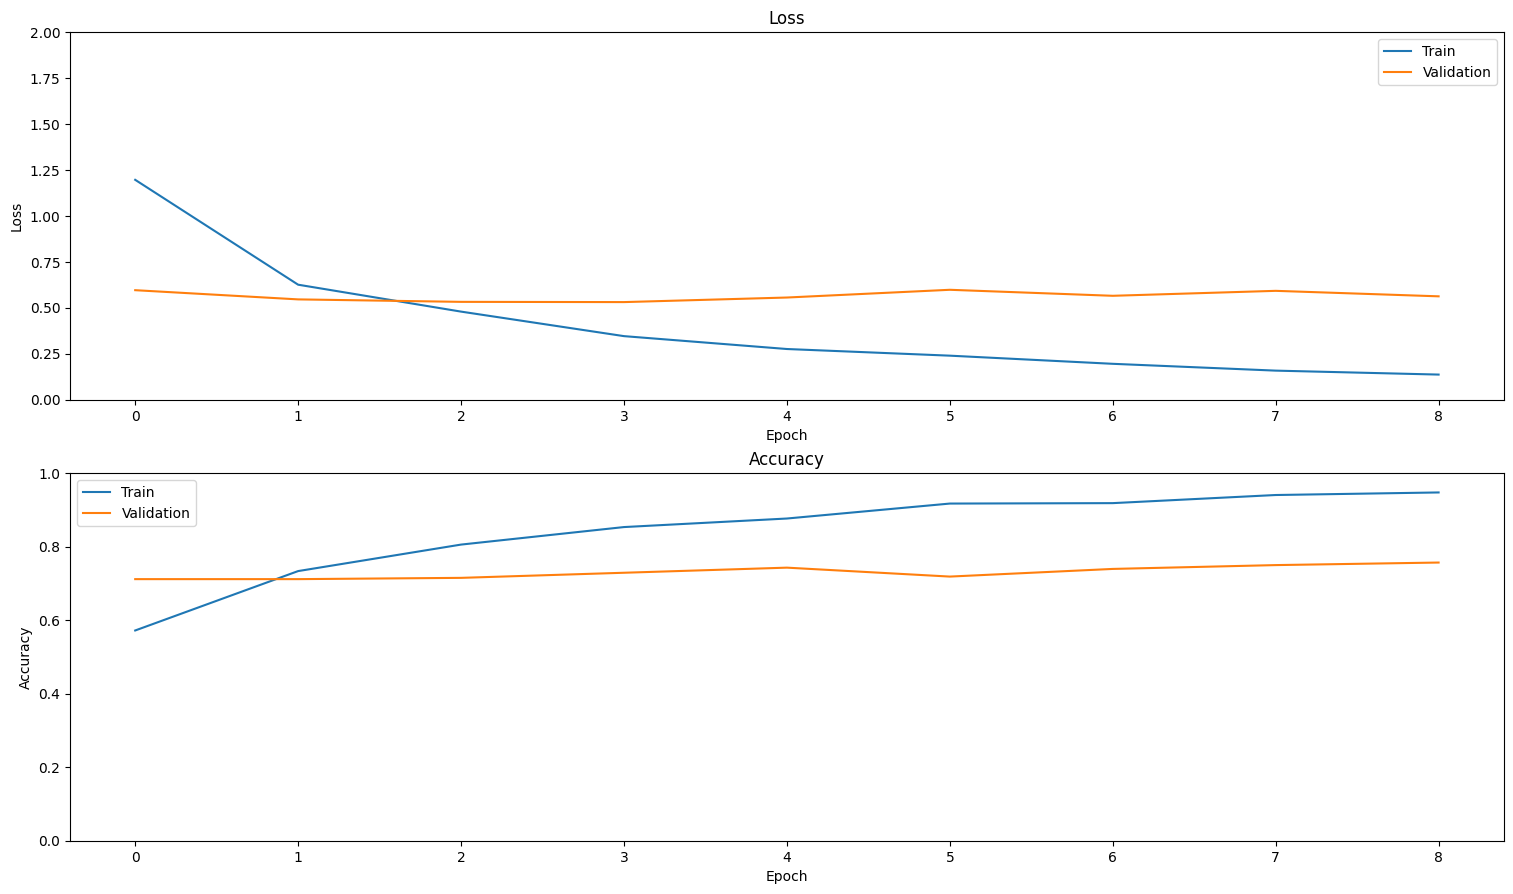

time: 539 ms (started: 2025-12-09 23:41:43 +00:00)


In [ ]:
plot_history(training_history, training_history_plot_save_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 928ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step


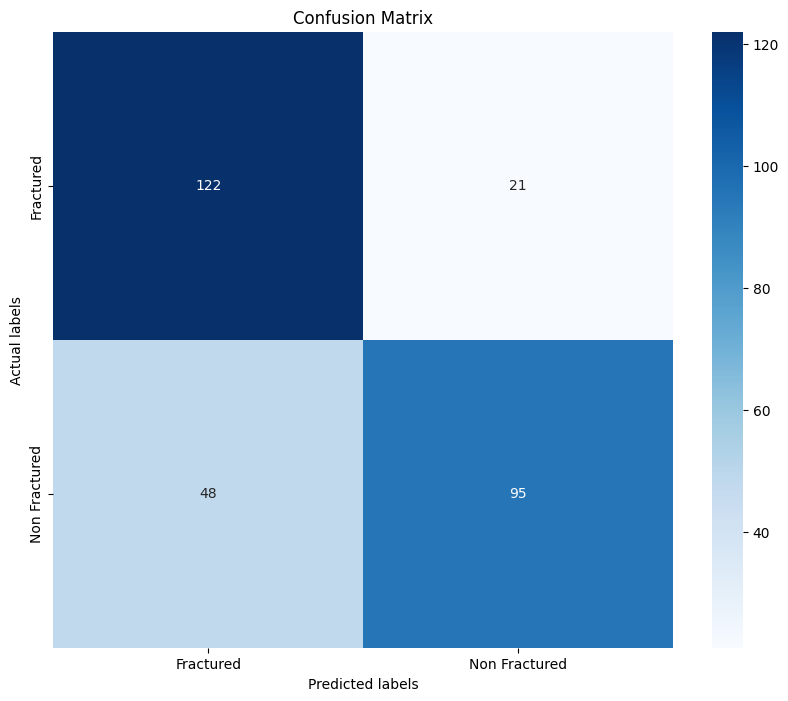

time: 12.5 s (started: 2025-12-09 23:41:44 +00:00)


In [ ]:
training_confusion_matrix = plot_confusion_matrix(test_ds, model, class_names, training_confusion_matrix_save_path)

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 732ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step

Final ROC AUC: 0.840



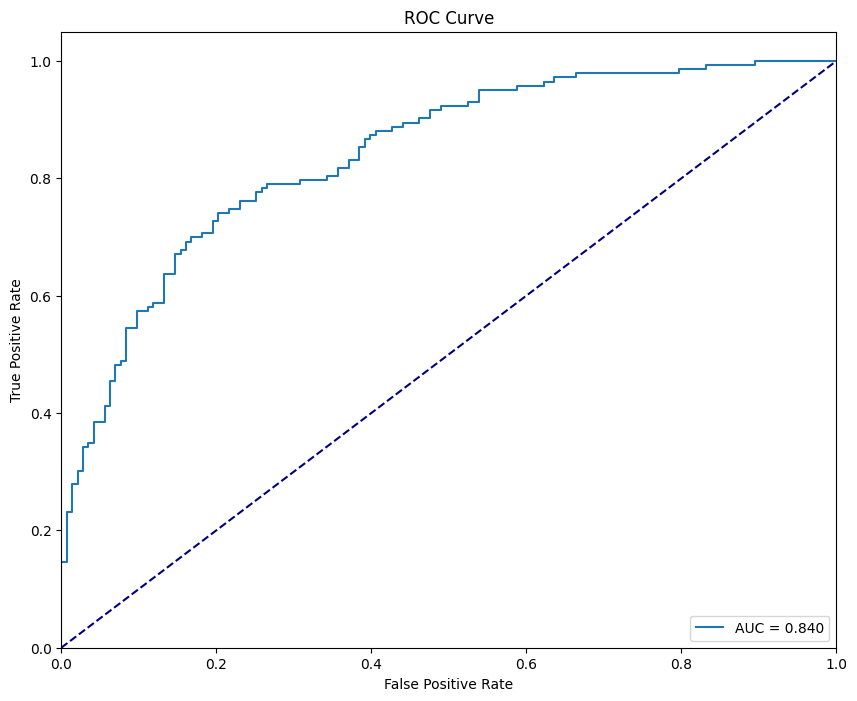

time: 12.5 s (started: 2025-12-09 23:41:56 +00:00)


In [ ]:
plot_roc_curve(model, test_ds, class_names, training_roc_curve_save_path, roc_auroc_csv_path, False)

### Grad-CAM Implementation

Grad-CAM (Gradient-weighted Class Activation Mapping) is a technique for making Convolutional Neural Network (CNN) models more transparent by visualizing the regions of an input image that are important for the model's prediction. It uses the gradients of the target concept (e.g., the predicted class) flowing into the final convolutional layer to produce a coarse localization map highlighting the important regions in the image.

Here's a breakdown of the steps:

1.  **Create a sub-model**: This model will take an input image and output both the feature maps from the last convolutional layer and the final predictions from the original model.
2.  **Compute Gradients**: Calculate the gradients of the predicted class's score with respect to the feature maps of the last convolutional layer.
3.  **Global Average Pooling (GAP)**: Perform global average pooling on these gradients to get 'neuron importance weights'. These weights signify the importance of each feature map channel for the predicted class.
4.  **Compute Heatmap**: Multiply each feature map by its corresponding importance weight and then sum them up. This results in an initial heatmap.
5.  **ReLU Activation**: Apply a ReLU function to the heatmap. This ensures that only the features that positively influence the class prediction are highlighted.
6.  **Normalize Heatmap**: Normalize the heatmap values to a range of 0 to 1 for proper visualization.
7.  **Superimpose**: Resize the heatmap to the original image dimensions and overlay it on the input image using a color map to visually represent the activated regions.

In [15]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradients of the top predicted class for our input image with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map array by "how important this channel is" with respect to the top predicted class
    # and then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

time: 1.21 ms (started: 2025-12-16 08:47:18 +00:00)


In [16]:
def display_gradcam(img, heatmap, alpha=0.4):
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use a colormap to colorize the heatmap
    jet = plt.colormaps['jet']

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    return superimposed_img

time: 894 µs (started: 2025-12-16 08:47:21 +00:00)


Now, let's load the trained model and select a few images from the test dataset to demonstrate Grad-CAM.

In [17]:
# Load the trained model
model = load_model('/content/drive/MyDrive/CSE425 Project/Preprocessing Result/Negative Image Result/ResNet101/training_model.keras')

# Get the name of the last convolutional layer dynamically
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name is None:
    raise ValueError("No Conv2D layer found in the model.")

print(f"Using last convolutional layer: {last_conv_layer_name} for Grad-CAM")

Using last convolutional layer: conv5_block3_3_conv for Grad-CAM
time: 8.57 s (started: 2025-12-16 08:47:23 +00:00)


### Load Specific Images for Grad-CAM

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


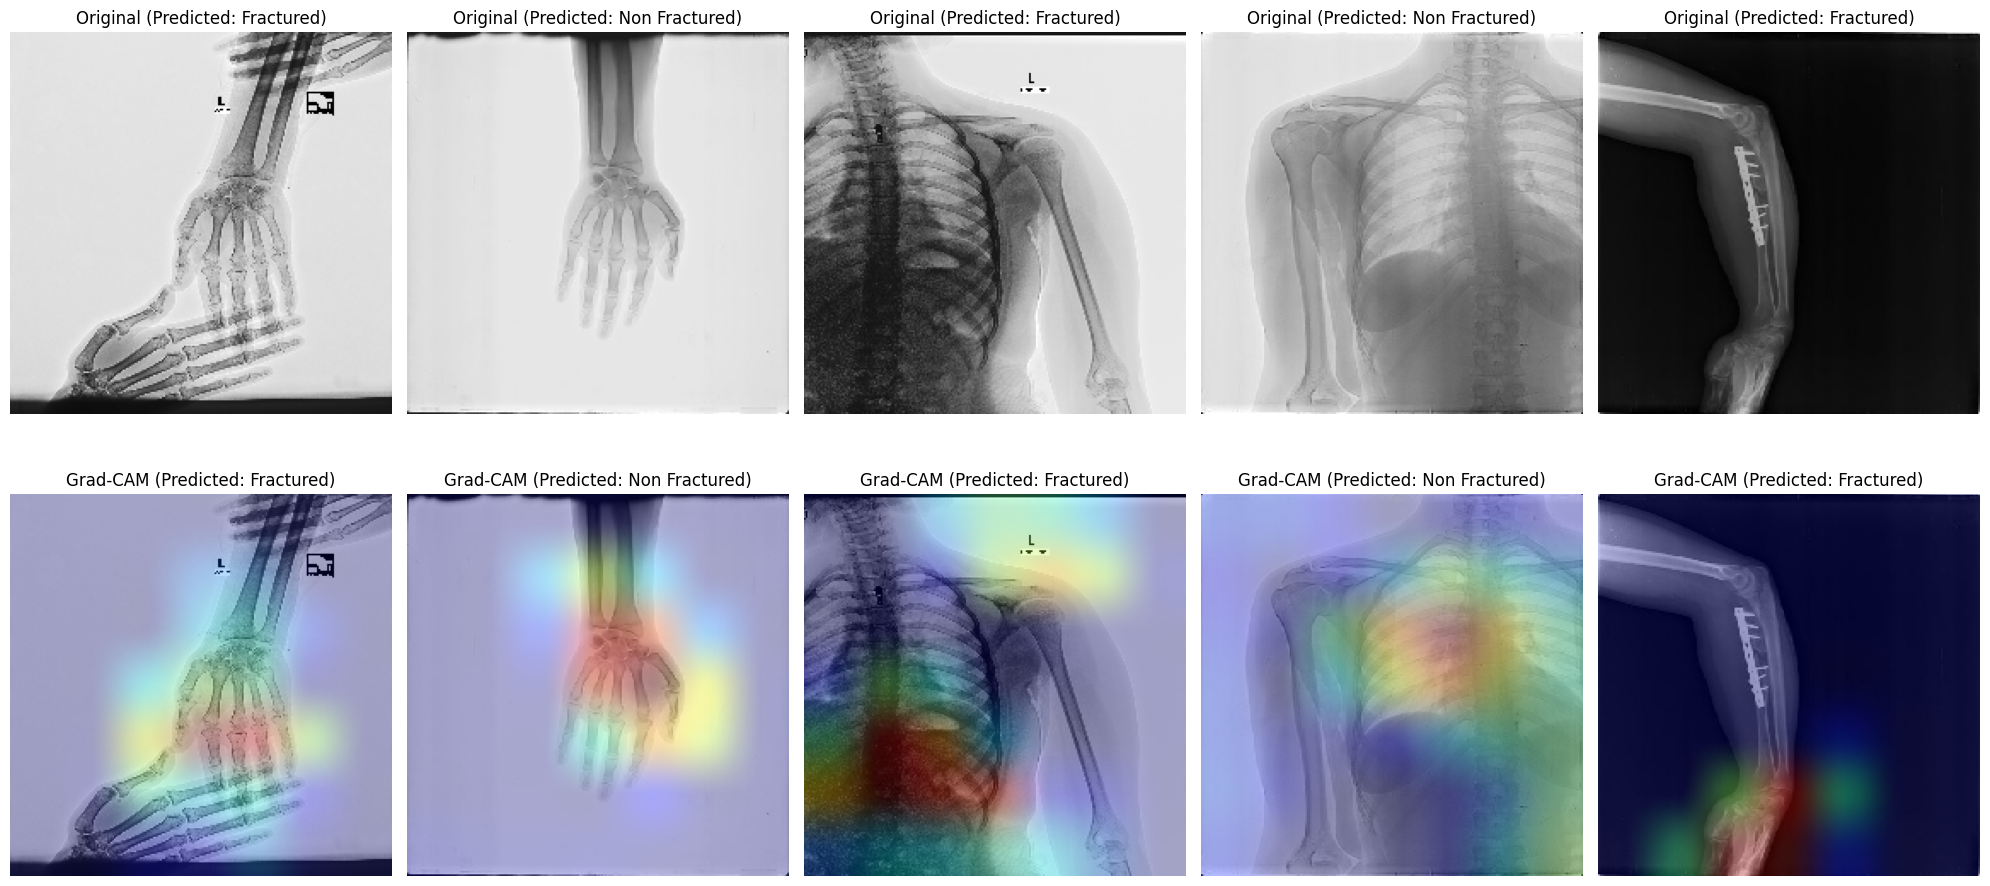

Grad-CAM images saved to: /content/drive/MyDrive/CSE425 Project/Preprocessing Result/Negative Image Result/ResNet101/Gradcam
time: 21 s (started: 2025-12-16 08:47:49 +00:00)


In [18]:
# Define the paths to your specific images
specific_image_paths = [
    '/content/drive/MyDrive/CSE425 Project/Preprocessed/Negative Image/Negative Dataset/Train/Fractured/IMG0000019.png',
    '/content/drive/MyDrive/CSE425 Project/Preprocessed/Negative Image/Negative Dataset/Train/Non Fractured/IMG0000644.png',
    '/content/drive/MyDrive/CSE425 Project/Preprocessed/Negative Image/Negative Dataset/Train/Fractured/IMG0000190.png',
    '/content/drive/MyDrive/CSE425 Project/Preprocessed/Negative Image/Negative Dataset/Train/Non Fractured/IMG0003221.png',
    '/content/drive/MyDrive/CSE425 Project/Preprocessed/Negative Image/Negative Dataset/Test/Fractured/IMG0002604.png'
]

specific_sample_images = []

# Define the base output directory for Grad-CAM images
gradcam_output_dir = '/content/drive/MyDrive/CSE425 Project/Preprocessing Result/Negative Image Result/ResNet101/Gradcam'
os.makedirs(gradcam_output_dir, exist_ok=True)

# Load and preprocess each image
for img_path in specific_image_paths:
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_height, img_width))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    # Normalization should match the training preprocessing. ResNet101 expects images normalized to [-1, 1] or [0, 1].
    # The dataset was likely generated with values from 0-255, so we rescale to 0-1 for consistency if not done by image_dataset_from_directory.
    # If the original model used `tf.keras.applications.resnet.preprocess_input`, apply it here.
    # For simplicity, if your model expects [0, 1] for images coming from image_dataset_from_directory, divide by 255.0
    # If your model expects ResNet's specific preprocessing, you'd use: img_array = tf.keras.applications.resnet.preprocess_input(img_array)
    specific_sample_images.append(img_array)


plt.figure(figsize=(20, 10))

for i, img_data in enumerate(specific_sample_images):
    img_tensor = tf.expand_dims(img_data, axis=0) # Add batch dimension
    original_img_display = img_data.astype(np.uint8) # Convert to uint8 for display

    # Make a prediction to get the predicted class for the title
    predictions = model.predict(img_tensor)
    # Sigmoid output: threshold at 0.5
    predicted_class_index = int(predictions[0][0] >= 0.5)
    predicted_class_name = class_names[predicted_class_index]

    # Get heatmap
    heatmap = make_gradcam_heatmap(img_tensor, model, last_conv_layer_name)

    # Superimpose heatmap on original image
    gradcam_img = display_gradcam(original_img_display, heatmap)

    # Generate base filename from original path
    original_filename = os.path.basename(specific_image_paths[i]).split('.')[0]

    # Save original image with prediction
    original_save_path = os.path.join(gradcam_output_dir, f'{original_filename}_original_predicted_{predicted_class_name}.png')
    tf.keras.preprocessing.image.array_to_img(original_img_display).save(original_save_path)

    # Save Grad-CAM image with prediction
    gradcam_save_path = os.path.join(gradcam_output_dir, f'{original_filename}_gradcam_predicted_{predicted_class_name}.png')
    gradcam_img.save(gradcam_save_path)


    # Display original image and Grad-CAM image
    plt.subplot(2, len(specific_sample_images), i + 1)
    plt.imshow(original_img_display)
    plt.title(f"Original (Predicted: {predicted_class_name})")
    plt.axis('off')

    plt.subplot(2, len(specific_sample_images), len(specific_sample_images) + i + 1)
    plt.imshow(gradcam_img)
    plt.title(f"Grad-CAM (Predicted: {predicted_class_name})")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Grad-CAM images saved to: {gradcam_output_dir}")